* **nombre**: Marcos Bianchi
* **padrón**: 108921

## 1. Implemente un perceptrón simple que aprenda la función lógica AND y la función lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos los vectores de entrada de la red.

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def plot_errors(errors: list[float], gate: str):
    xs = list(range(len(errors)))

    plt.plot(xs, errors)
    plt.title(f"Perceptron's classification error per epoch for an {gate} gate")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.xticks(xs)
    plt.grid(True)
    plt.show()


def plot_weights(ws: list[tuple[float, float, float]], gate: str):
    points = [(-1, -1), (-1, 1), (1, -1), (1, 1)]

    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    fig, axes = plt.subplots(1, len(ws), figsize=(6 * len(ws), 6), squeeze=False)

    for ax, (W, B) in zip(axes[0], ws):
        Z = W[0] * xx + W[1] * yy + B
        Z = np.sign(Z)

        ax.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=["#ffcccc", "#ccccff"])
        ax.contour(xx, yy, Z, levels=[0], colors="blue")

        xs, ys = zip(*points)
        ax.scatter(xs, ys, color="red", edgecolor="black", zorder=5, label="Points")

        ax.set_title(f"weights: ({W[0].item():.2f}, {W[1].item():.2f}, {B:.2f})")

        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True)

    fig.suptitle(f"Perceptron's classification per epoch for {gate} gate")
    plt.tight_layout()
    plt.show()

SEED = 1234

$$AND(2)$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|-1|
|-1|1|-1|
|-1|-1|-1|

In [2]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(2, seed=SEED)
X, Y = truth_table(2, lambda xs: 2 * all(x == 1 for x in xs) - 1)

ws, errors = [], []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=tracker)

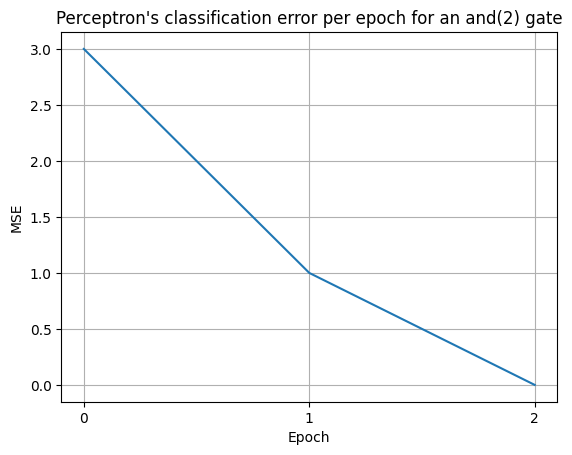

In [3]:
plot_errors(errors, "and(2)")

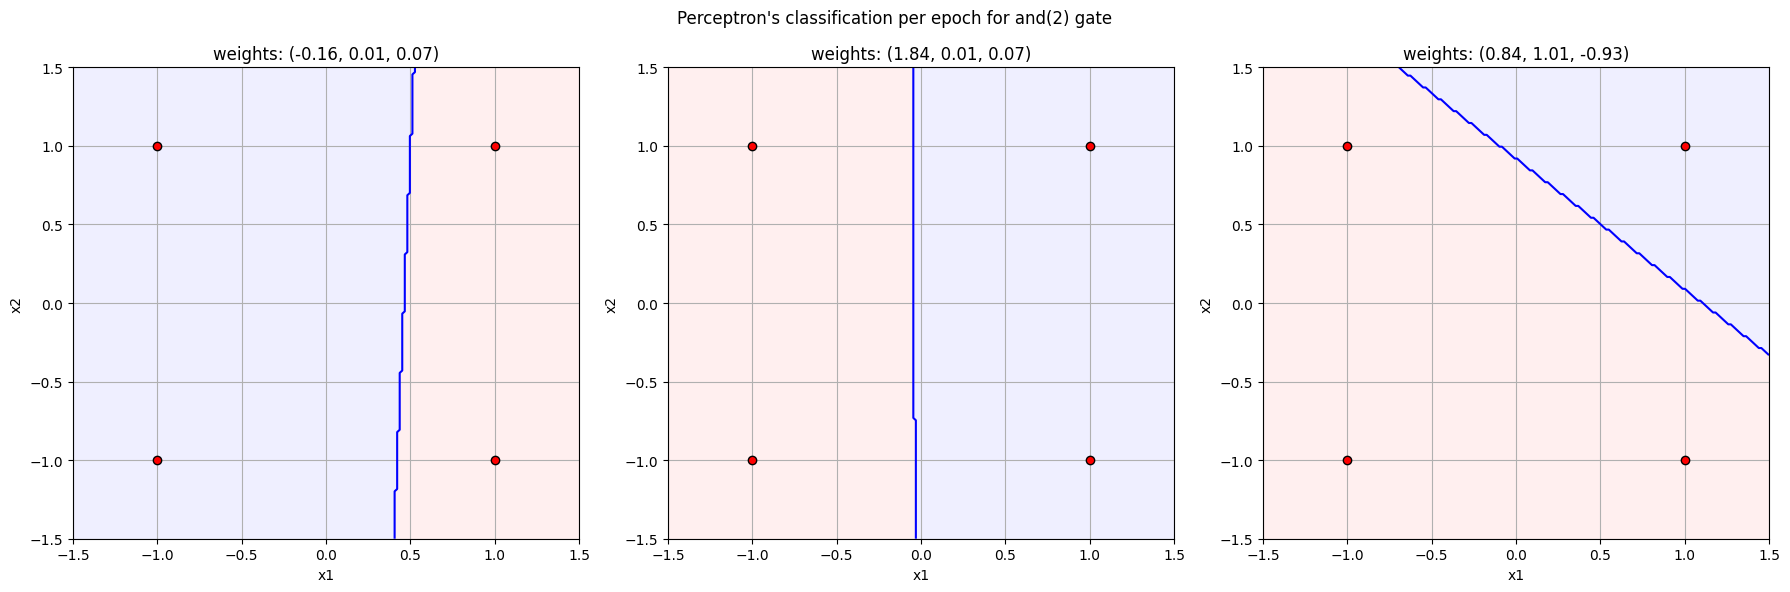

In [4]:
plot_weights(ws, "and(2)")

$$OR(2)$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|1|
|-1|1|1|
|-1|-1|-1|

In [5]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(2, seed=SEED)
X, Y = truth_table(2, lambda xs: 2 * any(x == 1 for x in xs) - 1)

ws, errors = [], []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=tracker)

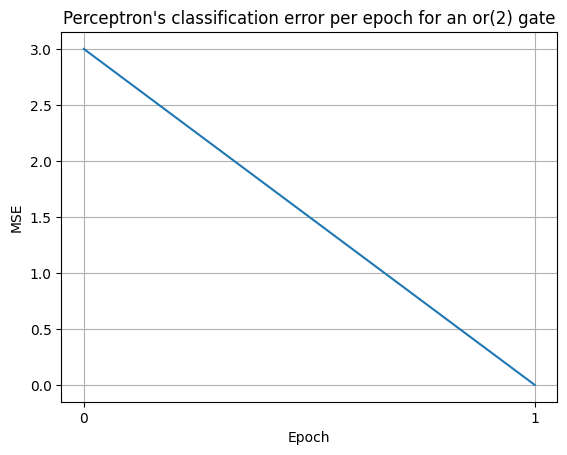

In [6]:
plot_errors(errors, "or(2)")

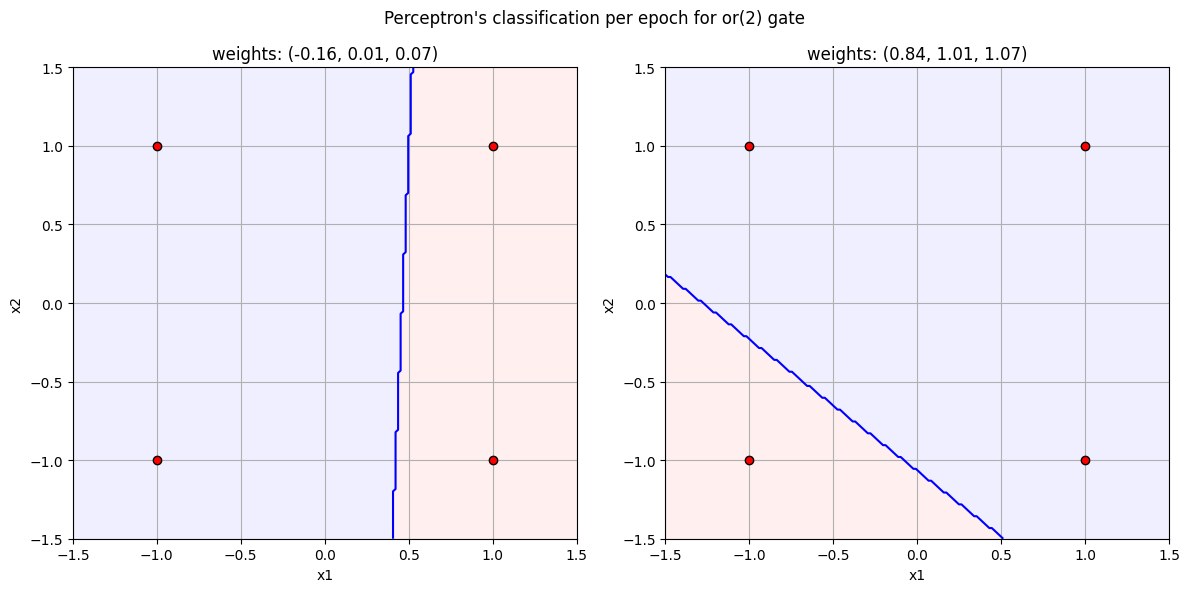

In [7]:
plot_weights(ws, "or(2)")

$$AND(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|1|
|1|1|1|-1|-1|
|1|1|-1|1|-1|
|1|1|-1|-1|-1|
|1|-1|1|1|-1|
|1|-1|1|-1|-1|
|1|-1|-1|1|-1|
|1|-1|-1|-1|-1|
|-1|1|1|1|-1|
|-1|1|1|-1|-1|
|-1|1|-1|1|-1|
|-1|1|-1|-1|-1|
|-1|-1|1|1|-1|
|-1|-1|1|-1|-1|
|-1|-1|-1|1|-1|
|-1|-1|-1|-1|-1|

In [8]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(4, seed=SEED)
X, Y = truth_table(4, lambda xs: 2 * all(x == 1 for x in xs) - 1)

errors = []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)

m.train(X, Y, epoch_f=tracker)

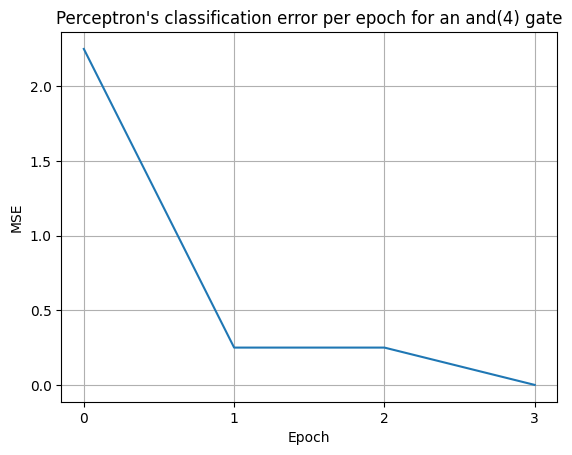

In [9]:
plot_errors(errors, "and(4)")

$$OR(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|1|
|1|1|1|-1|1|
|1|1|-1|1|1|
|1|1|-1|-1|1|
|1|-1|1|1|1|
|1|-1|1|-1|1|
|1|-1|-1|1|1|
|1|-1|-1|-1|1|
|-1|1|1|1|1|
|-1|1|1|-1|1|
|-1|1|-1|1|1|
|-1|1|-1|-1|1|
|-1|-1|1|1|1|
|-1|-1|1|-1|1|
|-1|-1|-1|1|1|
|-1|-1|-1|-1|-1|

In [10]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(4, seed=SEED)
X, Y = truth_table(4, lambda xs: 2 * any(x == 1 for x in xs) - 1)

errors = []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)

m.train(X, Y, epoch_f=tracker)

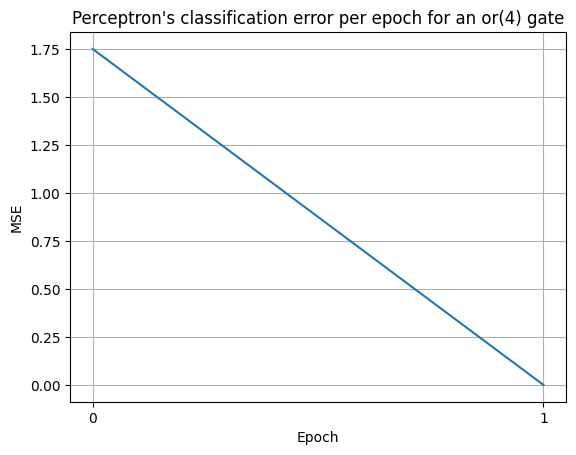

In [11]:
plot_errors(errors, "or(4)")

## 2. Determine numéricamente cómo varía la capacidad del perceptrón simple en funció ndel número de patrones enseñados.

In [14]:
from src.perceptron import Perceptron
import matplotlib.pyplot as plt
import numpy as np


n, n_t = 20, 250
xs = np.arange(1, 4 * n + 1, 2)
ys = [Perceptron.capacity(n, n_p, n_t, seed=SEED, max_iter=100) for n_p in xs]

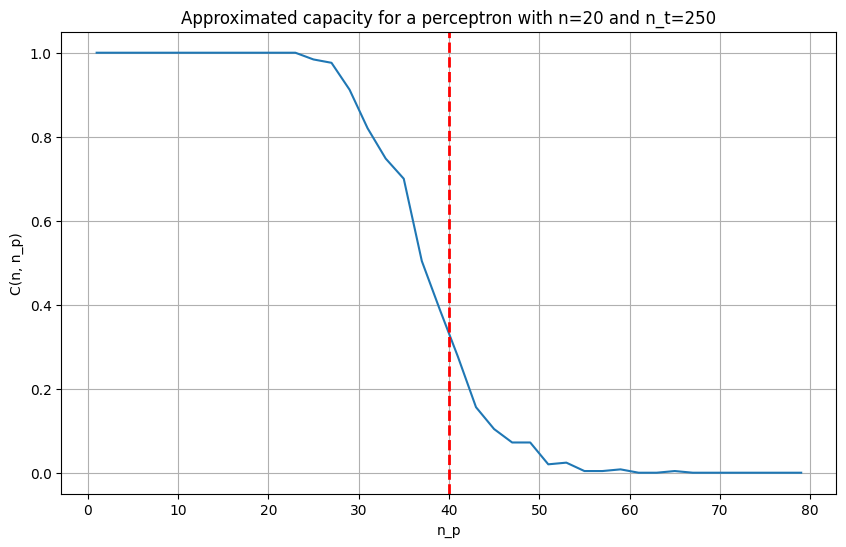

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(xs, ys)
plt.title(f"Approximated capacity for a perceptron with n={n} and n_t={n_t}")
plt.axvline(x=2 * n, color="red", linestyle="--", linewidth=2)
plt.xlabel("n_p")
plt.ylabel("C(n, n_p)")
plt.grid(True)
plt.show()

### 3. Implemente un perceptrón multicapa que aprenda la función lógica XOR de 2 y de 4 entradas (utilizando el algoritmo Backpropagation y actualizando en batch). Muestre cómo evoluciona el error durante el entrenamiento.

In [1]:
SEED = 1234

from src.mlp import MLP
from src.layer import Dense, Tanh
from src.utils import truth_table

arch = [
    Dense(2, 2, seed=SEED),
    Tanh(2),
    Dense(2, 1, seed=SEED),
    Tanh(1),
]

m = MLP(arch    seed=SEED,
)
X, Y = truth_table(2, lambda xs: 2 * (xs.count(1) == 1) - 1)

m.train(X, Y, lr=0.1)

In [2]:
import numpy as np

print(m.forward(X))

[[-0.98239765]
 [ 0.97602598]
 [ 0.97561395]
 [-0.98239367]]
